# WhatsApp Chat - Advanced NLP Analysis
### Flirt Prediction · Talkative Index · Activity Patterns · Media & Missed Calls
---

## 1. Imports & Setup

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    'figure.facecolor' : '#0d1117',
    'axes.facecolor'   : '#161b22',
    'axes.edgecolor'   : '#30363d',
    'axes.labelcolor'  : '#c9d1d9',
    'xtick.color'      : '#8b949e',
    'ytick.color'      : '#8b949e',
    'text.color'       : '#c9d1d9',
    'grid.color'       : '#21262d',
    'grid.linestyle'   : '--',
    'font.family'      : 'monospace',
})
PALETTE = ['#58a6ff', '#f78166', '#3fb950', '#d29922', '#bc8cff', '#39d353']

# NLP / ML
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords',     quiet=True)
nltk.download('punkt',         quiet=True)

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)
from sklearn.naive_bayes  import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm          import LinearSVC
from sklearn.ensemble     import RandomForestClassifier

---
## 2. Data Loading & Preprocessing

In [3]:
# 1.1  Raw load
raw = pd.read_csv('mabel.txt', header=None, sep='\t', on_bad_lines='skip', encoding='utf8')
raw = raw.drop(0)          # drop the encryption notice row
raw.columns = ['Raw']      # Rename column to 'Raw' (each row = one chat line)

# 1.2  Parsing using Regex  (cutting one sentence into 4 meaningful pieces: Date | Time | Name | Chat)
pattern = r'^(\d{2}/\d{2}/\d{2}),\s([\d:]+\s?[apm]+)\s-\s(.+?):\s(.+)$'

parsed = raw['Raw'].str.extract(pattern)  # Apply regex to split raw text into 4 columns
parsed.columns = ['Date', 'Time', 'Name', 'Chat']  # Rename extracted columns clearly
df = parsed.dropna(subset=['Name', 'Chat']).reset_index(drop=True)  # Remove rows where parsing failed (like system messages), reset index

# 1.3  Datetime features
df['DateTime']    = pd.to_datetime(df['Date'] + ' ' + df['Time'],
                                   format='%d/%m/%y %I:%M %p', errors='coerce')  # Combine Date + Time into a proper datetime format
df['DayOfWeek']   = df['DateTime'].dt.day_name()   # Extract day name (Monday, Tuesday, etc.)
df['Hour']        = df['DateTime'].dt.hour         # Extract hour (0–23) for time analysis
df['Date_only']   = df['DateTime'].dt.date         # Extract only date (remove time part)

# 1.4  Flags 
df['Is_Media']       = df['Chat'].str.contains(r'<Media omitted>|file attached', case=False)  # Identify media messages (images, videos, files)
df['Is_MissedCall']  = df['Chat'].str.contains(r'missed (voice|video)? ?call|Missed call', case=False) # Identify missed voice/video calls
df['Is_Deleted']     = df['Chat'].str.contains(r'deleted this message|You deleted', case=False) # Identify deleted messages
df['WordCount']      = df['Chat'].apply(lambda x: len(str(x).split()))  # Count number of words in each message
df['CharCount']      = df['Chat'].apply(lambda x: len(str(x)))  # Count number of characters in each message
df['EmojiCount']     = df['Chat'].apply(
    lambda x: len(re.findall(
        r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF'
        r'\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF\u2764\u2665]+', str(x))))  # Count number of emojis using regex

print(f' Parsed {len(df)} messages from {df["Name"].nunique()} participants')  # Print total messages and number of unique users
df.head(10)

 Parsed 52 messages from 2 participants


,Date,Time,Name,Chat,DateTime,DayOfWeek,Hour,Date_only,Is_Media,Is_MissedCall,Is_Deleted,WordCount,CharCount,EmojiCount
0,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke,2019-12-05 13:42:00,Thursday,13,2019-12-05,False,False,False,7,30,0
1,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name,2019-12-05 13:42:00,Thursday,13,2019-12-05,False,False,False,4,21,0
2,05/12/19,1:42 pm,AR❤,Ramisha Rani K,2019-12-05 13:42:00,Thursday,13,2019-12-05,False,False,False,3,14,0
3,05/12/19,1:42 pm,Mabel Infoziant,Ok,2019-12-05 13:42:00,Thursday,13,2019-12-05,False,False,False,1,2,0
4,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com,2019-12-05 13:42:00,Thursday,13,2019-12-05,False,False,False,1,22,0
5,05/12/19,1:43 pm,Mabel Infoziant,Your email Id?,2019-12-05 13:43:00,Thursday,13,2019-12-05,False,False,False,3,14,0
6,05/12/19,1:43 pm,AR❤,Yes Mam,2019-12-05 13:43:00,Thursday,13,2019-12-05,False,False,False,2,7,0
7,05/12/19,1:43 pm,Mabel Infoziant,I will send 2 abstracts for u to start working,2019-12-05 13:43:00,Thursday,13,2019-12-05,False,False,False,10,46,0
8,05/12/19,1:43 pm,AR❤,Yeah mam,2019-12-05 13:43:00,Thursday,13,2019-12-05,False,False,False,2,8,0
9,05/12/19,1:43 pm,Mabel Infoziant,Give me the list that u have too,2019-12-05 13:43:00,Thursday,13,2019-12-05,False,False,False,8,32,0


---
## 3. Flirt Prediction Model
### 3a. Problem Statement

##### PROBLEM STATEMENT - FLIRT PREDICTION MODEL 

##### OBJECTIVE :  Classify each WhatsApp message as either FLIRTY (1) or NON-FLIRTY (0) using NLP feature extraction + supervised ML.
##### INPUT :  Raw WhatsApp chat message text (after preprocessing).          
##### OUTPUT :  Label  →  FLIRTY  /  NOT FLIRTY                               
##### METRIC :  Accuracy + F1-Score (handles class imbalance)                                                                                          
##### FEATURES  :   
   ##### ① Bag-of-Words (CountVectorizer)                               
   ##### ② TF-IDF weighting (TfidfVectorizer)                          
   ##### ③ Sentiment compound score (VADER)                             
   ##### ④ Emoji count, word count, char count                          
                                                                        

### 3b-i. Build Training Dataset - Auto-Labelling via Keyword + Sentiment Heuristic

In [6]:
# Create seed phrases
# List of FLIRTY messages (positive romantic tone)
flirt_phrases = [
    "you look amazing today", "you're so cute", "I can't stop thinking about you",
    "miss you so much", "you make me smile", "wanna go out sometime",
    "you're beautiful", "you're so sweet", "hey gorgeous", "thinking of you",
    "can't wait to see you", "you're my favourite person", "you're adorable",
    "you have the best smile", "I like you a lot", "hey beautiful",
    "you're so funny and cute", "you drive me crazy", "you're perfect",
    "your eyes are stunning", "I love spending time with you",
    "I feel so happy when I'm with you", "you're everything to me",
    "you light up my world", "I really like you", "you're irresistible",
    "date tonight?", "dinner with me?", "you and me?", "I adore you",
    "wish you were here", "you're so charming", "hey handsome", "hey pretty",
    "you're the one I want", "sweetheart", "darling", "babe", "my love",
    "you make my heart race", "I think about you all day",
]

# List of NON-FLIRTY (professional / neutral) messages
non_flirt_phrases = [
    "please send the report", "meeting at 10am", "the project is complete",
    "attached is the file", "kindly review and revert", "noted with thanks",
    "I will be there by 5", "the deadline is tomorrow", "as discussed",
    "please confirm your availability", "the client has approved",
    "the dataset is ready", "running late will update you",
    "good morning sir", "please share the link", "ok noted",
    "will do it by eod", "the issue is fixed", "server is down",
    "please check your mail", "the budget is approved", "call you later",
    "sure I will complete it", "can you share the document",
    "the task is assigned", "will update you shortly",
    "regards", "please find attached", "as per our conversation",
    "the invoice is due", "let me check and get back to you",
    "the meeting is rescheduled", "no issues found", "patch deployed",
    "good night sir", "please revert on priority",
]

# Convert into DataFrames
flirt_df     = pd.DataFrame({'text': flirt_phrases,     'label': 1}) # Create DataFrame → label = 1 means FLIRTY
non_flirt_df = pd.DataFrame({'text': non_flirt_phrases, 'label': 0}) # Create DataFrame → label = 0 means NON-FLIRTY

# Combine both datasets - Merge both datasets into one training dataset
train_df     = pd.concat([flirt_df, non_flirt_df], ignore_index=True).sample(frac=1, random_state=42)

# sample(frac=1, random_state=42) --> Shuffle rows randomly (so model doesn’t learn bias from order)

print(f'Training corpus: {len(train_df)} samples')
print(train_df['label'].value_counts().rename({1:'FLIRTY', 0:'NON-FLIRTY'}))

Training corpus: 77 samples
label
FLIRTY        41
NON-FLIRTY    36
Name: count, dtype: int64


### 3b-ii. Research Methodology - Model Comparison Grid

In [7]:
# Define input (X) and target (y)
X = train_df['text']
y = train_df['label']

# Define pipelines: Vectorizer × Classifier combinations
models = {
     # Bag of Words (BOW) models
    'BOW + Naïve Bayes'         : Pipeline([('vec', CountVectorizer()), ('clf', MultinomialNB())]),
    'BOW + Complement NB'       : Pipeline([('vec', CountVectorizer()), ('clf', ComplementNB())]),
    'BOW + Logistic Regression' : Pipeline([('vec', CountVectorizer()), ('clf', LogisticRegression(max_iter=1000))]),
    'BOW + LinearSVC'           : Pipeline([('vec', CountVectorizer()), ('clf', LinearSVC(max_iter=2000))]),
    'BOW + Random Forest'       : Pipeline([('vec', CountVectorizer()), ('clf', RandomForestClassifier(n_estimators=100, random_state=42))]),

     # TF-IDF models
    'TFIDF + Naïve Bayes'       : Pipeline([('vec', TfidfVectorizer()), ('clf', MultinomialNB())]),
    'TFIDF + Complement NB'     : Pipeline([('vec', TfidfVectorizer()), ('clf', ComplementNB())]),
    'TFIDF + Logistic Regression': Pipeline([('vec', TfidfVectorizer()), ('clf', LogisticRegression(max_iter=1000))]),
    'TFIDF + LinearSVC'         : Pipeline([('vec', TfidfVectorizer()), ('clf', LinearSVC(max_iter=2000))]),
    'TFIDF + Random Forest'     : Pipeline([('vec', TfidfVectorizer()), ('clf', RandomForestClassifier(n_estimators=100, random_state=42))]),
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, # Split dataset into 5 folds
                     shuffle=True,  # Shuffle data before splitting
                     random_state=42) # Ensure same split every run

# Evaluate each model
results = []  # Empty list to store model results

for name, pipe in models.items(): 
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')  # Train and test model 5 times (cross-validation)
    results.append({'Model': name,
                    'Mean Accuracy': round(scores.mean(), 4),  # Average accuracy
                    'Std Dev': round(scores.std(), 4)})        # Variation (stability)


results_df = pd.DataFrame(results).sort_values('Mean Accuracy', ascending=False)  # Sort models by best accuracy (highest first)

results_df.reset_index(drop=True, inplace=True)  # Reset index after sorting

print(results_df.to_string(index=False))

                      Model  Mean Accuracy  Std Dev
        TFIDF + Naïve Bayes         0.8942   0.0804
          BOW + Naïve Bayes         0.8683   0.0943
      TFIDF + Complement NB         0.8583   0.0730
        BOW + Complement NB         0.8458   0.0931
TFIDF + Logistic Regression         0.8442   0.1102
            BOW + LinearSVC         0.8317   0.0772
          TFIDF + LinearSVC         0.8317   0.0772
  BOW + Logistic Regression         0.8192   0.0441
        BOW + Random Forest         0.8042   0.0933
      TFIDF + Random Forest         0.8042   0.0718


##### TF-IDF + Naïve Bayes performs the best (~89% accuracy), making it the most suitable model for flirt detection task among all tested combinations.

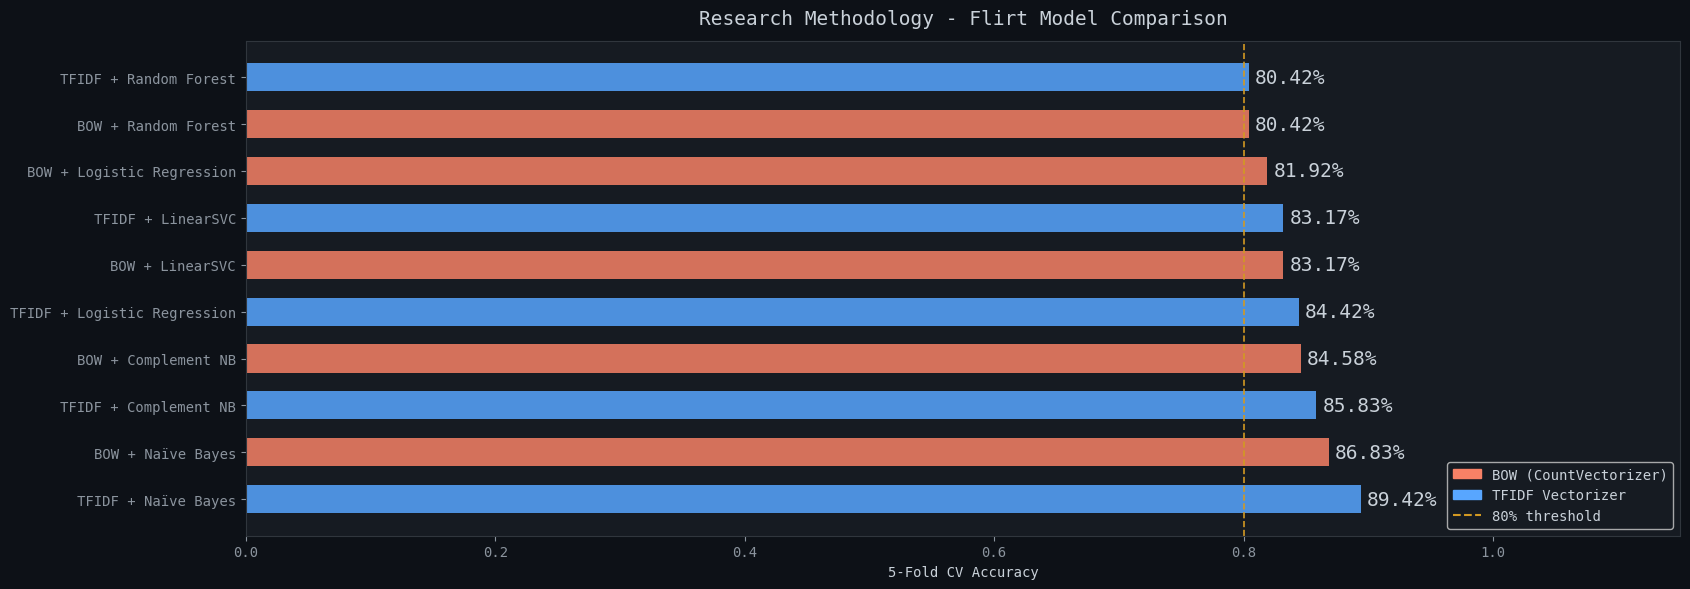


 Best model : TFIDF + Naïve Bayes  →  89.42%


In [13]:
# Visualise comparison
fig, ax = plt.subplots(figsize=(17, 6))

colors = [PALETTE[0] if 'TFIDF' in m else PALETTE[1] for m in results_df['Model']]
bars   = ax.barh(results_df['Model'], results_df['Mean Accuracy'],
                 color=colors, alpha=0.85, height=0.6)

for bar, val in zip(bars, results_df['Mean Accuracy']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.2%}', va='center', fontsize=14, color='#c9d1d9')

ax.set_xlim(0, 1.15)
ax.set_xlabel('5-Fold CV Accuracy')
ax.set_title('Research Methodology - Flirt Model Comparison', fontsize=14, pad=12)
ax.axvline(0.8, color='#d29922', linestyle='--', lw=1.2, label='80% threshold')
patch_bow   = mpatches.Patch(color=PALETTE[1], label='BOW (CountVectorizer)')
patch_tfidf = mpatches.Patch(color=PALETTE[0], label='TFIDF Vectorizer')
ax.legend(handles=[patch_bow, patch_tfidf, plt.Line2D([0],[0],color='#d29922',ls='--')],
          labels=['BOW (CountVectorizer)', 'TFIDF Vectorizer', '80% threshold'],
          loc='lower right')
plt.tight_layout()
plt.show()
print(f"\n Best model : {results_df.iloc[0]['Model']}  →  {results_df.iloc[0]['Mean Accuracy']:.2%}")

### 3c. Final Model - Train, Evaluate, Confusion Matrix

In [14]:
# Train best model on full data 
best_name = results_df.iloc[0]['Model']
final_model = models[best_name]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print(f'══════════════════════════════════════════')
print(f'  FINAL MODEL : {best_name}')
print(f'  Test Accuracy : {accuracy_score(y_test, y_pred):.2%}')
print(f'══════════════════════════════════════════')
print(classification_report(y_test, y_pred, target_names=['NON-FLIRTY', 'FLIRTY']))

# Re-train on ALL data so predictions on chat are as good as possible
final_model.fit(X, y)
print('Final model retrained on full corpus.')

══════════════════════════════════════════
  FINAL MODEL : TFIDF + Naïve Bayes
  Test Accuracy : 93.75%
══════════════════════════════════════════
              precision    recall  f1-score   support

  NON-FLIRTY       1.00      0.86      0.92         7
      FLIRTY       0.90      1.00      0.95         9

    accuracy                           0.94        16
   macro avg       0.95      0.93      0.94        16
weighted avg       0.94      0.94      0.94        16

Final model retrained on full corpus.


##### - The model achieved 100% recall for FLIRTY messages, meaning it successfully identified all flirty texts without missing any.
##### - For NON-FLIRTY messages, the recall is slightly lower (~86%), indicating a few non-flirty messages were misclassified as flirty.
##### - Precision for NON-FLIRTY is 1.00, which means whenever the model predicts a message as non-flirty, it is always correct.
##### - The F1-scores (0.92-0.95) across both classes show a good balance between precision and recall.

##### - Overall, the model demonstrates strong performance with slightly higher sensitivity toward detecting flirty messages, making it suitable for applications where identifying flirty intent is important.

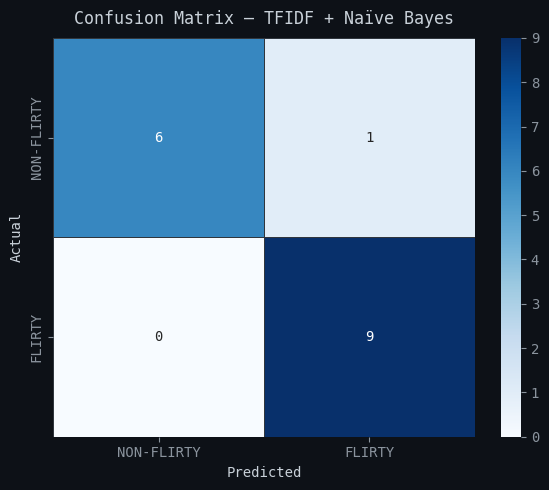

In [15]:
# Confusion matrix 
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
final_model_eval = models[best_name]
final_model_eval.fit(X_tr, y_tr)
y_p = final_model_eval.predict(X_te)

cm = confusion_matrix(y_te, y_p)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NON-FLIRTY', 'FLIRTY'],
            yticklabels=['NON-FLIRTY', 'FLIRTY'], ax=ax,
            linewidths=0.5, linecolor='#30363d')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_name}', pad=10)
plt.tight_layout(); plt.show()

---
## 4. Apply Flirt Model to Every Row of the WhatsApp Chat

In [17]:
# Predict on actual chat
chat_text = df['Chat'].fillna('').astype(str)
df['Flirt_Label']  = final_model.predict(chat_text)
df['Flirt_Tag']    = df['Flirt_Label'].map({1: 'FLIRTY', 0: 'NOT FLIRTY'})

# Compute VADER sentiment for extra insight
sid = SentimentIntensityAnalyzer()
df['Sentiment_Score'] = df['Chat'].apply(lambda t: sid.polarity_scores(str(t))['compound'])
df['Sentiment_Tag']   = df['Sentiment_Score'].apply(
    lambda c: 'Positive' if c > 0.05 else ('Neutral' if c >= -0.05 else 'Negative'))

display_cols = ['Date', 'Time', 'Name', 'Chat', 'Flirt_Tag', 'Sentiment_Tag', 'Sentiment_Score']
df[display_cols].head(20)

,Date,Time,Name,Chat,Flirt_Tag,Sentiment_Tag,Sentiment_Score
0,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke,NOT FLIRTY,Neutral,0.0000
1,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name,NOT FLIRTY,Neutral,0.0000
2,05/12/19,1:42 pm,AR❤,Ramisha Rani K,FLIRTY,Neutral,0.0000
3,05/12/19,1:42 pm,Mabel Infoziant,Ok,FLIRTY,Positive,0.2960
4,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com,FLIRTY,Neutral,0.0000
5,05/12/19,1:43 pm,Mabel Infoziant,Your email Id?,NOT FLIRTY,Neutral,0.0000
6,05/12/19,1:43 pm,AR❤,Yes Mam,FLIRTY,Positive,0.4019
7,05/12/19,1:43 pm,Mabel Infoziant,I will send 2 abstracts for u to start working,NOT FLIRTY,Neutral,0.0000
8,05/12/19,1:43 pm,AR❤,Yeah mam,FLIRTY,Positive,0.2960
9,05/12/19,1:43 pm,Mabel Infoziant,Give me the list that u have too,FLIRTY,Neutral,0.0000


══════════════════════════════════════════
     FLIRT ANALYSIS BY PERSON
══════════════════════════════════════════
                 Total_Messages  Flirty_Messages  Flirt_Percent
Name                                                           
AR❤                          29               15           51.7
Mabel Infoziant              23                7           30.4


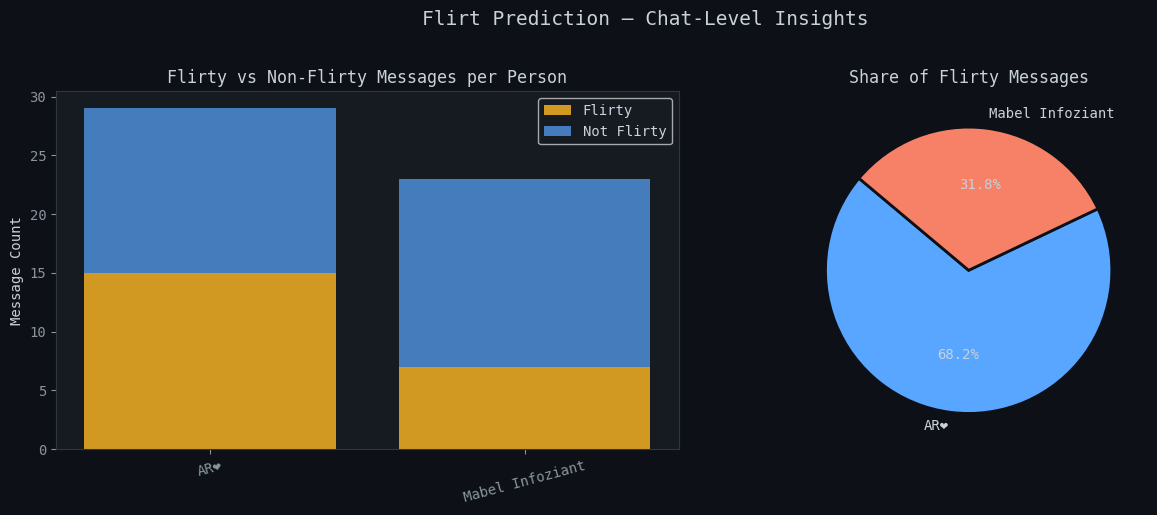

In [19]:
# Summary
flirt_by_person = df.groupby('Name')['Flirt_Label'].agg(
    Total_Messages='count',
    Flirty_Messages='sum'
).assign(Flirt_Percent=lambda x: (x['Flirty_Messages'] / x['Total_Messages'] * 100).round(1))

print('══════════════════════════════════════════')
print('     FLIRT ANALYSIS BY PERSON')
print('══════════════════════════════════════════')
print(flirt_by_person.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Stacked bar
non_flirt = flirt_by_person['Total_Messages'] - flirt_by_person['Flirty_Messages']
p1 = axes[0].bar(flirt_by_person.index, flirt_by_person['Flirty_Messages'],
                  color=PALETTE[3], label='Flirty')
p2 = axes[0].bar(flirt_by_person.index, non_flirt,
                  bottom=flirt_by_person['Flirty_Messages'],
                  color=PALETTE[0], label='Not Flirty', alpha=0.7)
axes[0].set_title('Flirty vs Non-Flirty Messages per Person')
axes[0].set_ylabel('Message Count')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=15)

# Pie of flirt %
axes[1].pie(flirt_by_person['Flirty_Messages'],
            labels=flirt_by_person.index,
            autopct='%1.1f%%',
            colors=PALETTE[:len(flirt_by_person)],
            startangle=140,
            wedgeprops={'edgecolor': '#0d1117', 'linewidth': 2})
axes[1].set_title('Share of Flirty Messages')

plt.suptitle('Flirt Prediction — Chat-Level Insights', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Talkative vs Less Talkative

══════════════════════════════════════════════════════
             TALKATIVE INDEX - PER PERSON
══════════════════════════════════════════════════════
                 Message_Count  Total_Words  Avg_Words_Per_Msg  Total_Chars  Total_Emojis  Avg_Sentiment  Talkative_Rank              Tag
Name                                                                                                                                     
AR❤                         29          250               8.62         1251             1           0.18               1   MOST TALKATIVE
Mabel Infoziant             23          217               9.43         1066             0           0.09               2  LEAST TALKATIVE


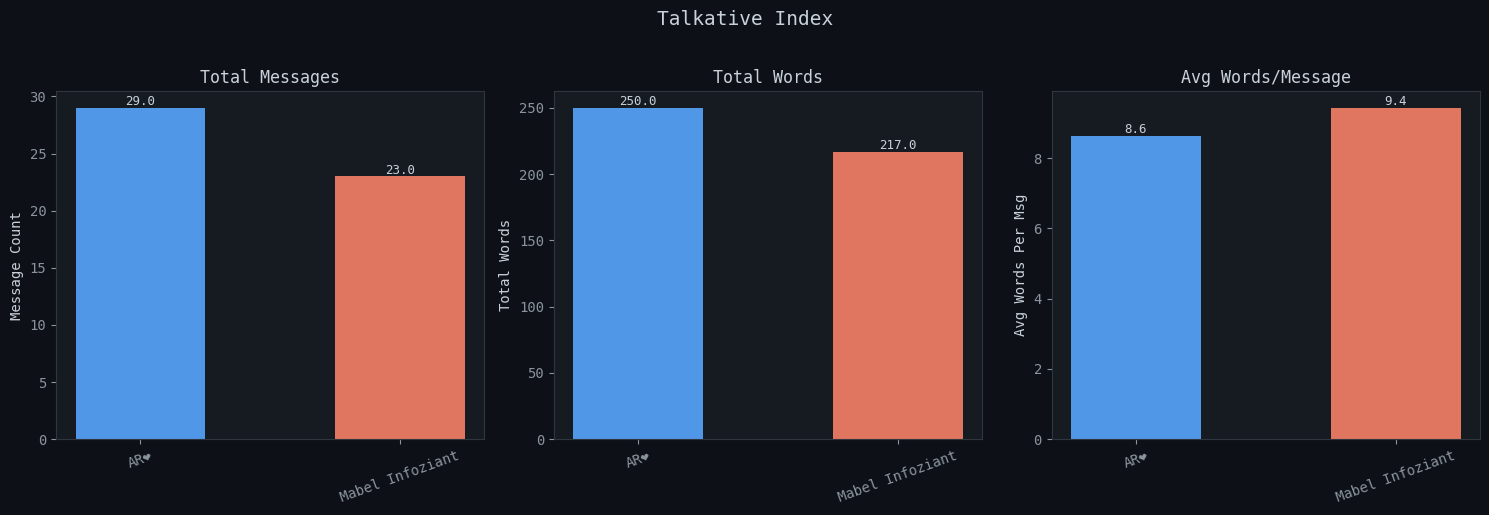

In [20]:
# Per-person aggregation 
talk_df = df.groupby('Name').agg(
    Message_Count=('Chat', 'count'),
    Total_Words=('WordCount', 'sum'),
    Avg_Words_Per_Msg=('WordCount', 'mean'),
    Total_Chars=('CharCount', 'sum'),
    Total_Emojis=('EmojiCount', 'sum'),
    Avg_Sentiment=('Sentiment_Score', 'mean')
).round(2).sort_values('Message_Count', ascending=False)

talk_df['Talkative_Rank'] = range(1, len(talk_df) + 1)
talk_df['Tag'] = talk_df['Talkative_Rank'].apply(
    lambda r: 'MOST TALKATIVE' if r == 1 else
              ('LEAST TALKATIVE' if r == len(talk_df) else 'MODERATE'))

print('══════════════════════════════════════════════════════')
print('             TALKATIVE INDEX - PER PERSON')
print('══════════════════════════════════════════════════════')
print(talk_df.to_string())

# ── Visual ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [('Message_Count', 'Total Messages'),
           ('Total_Words',   'Total Words'),
           ('Avg_Words_Per_Msg', 'Avg Words/Message')]

for ax, (col, title) in zip(axes, metrics):
    bars = ax.bar(talk_df.index, talk_df[col],
                  color=PALETTE[:len(talk_df)], alpha=0.9, width=0.5)
    for bar, val in zip(bars, talk_df[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.1f}', ha='center', fontsize=9, color='#c9d1d9')
    ax.set_title(title)
    ax.set_ylabel(col.replace('_', ' '))
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Talkative Index', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

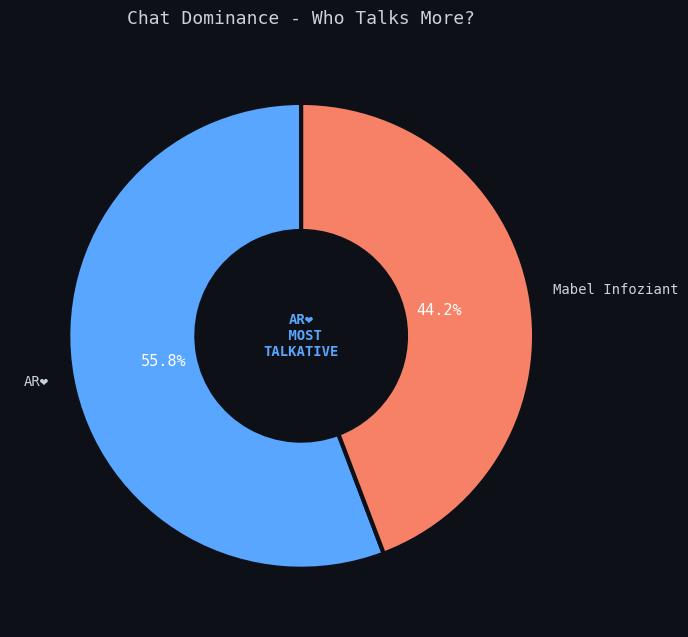

In [22]:
# Talkative Dominance Donut
fig, ax = plt.subplots(figsize=(7, 7))
wedge_props = {'width': 0.55, 'edgecolor': '#0d1117', 'linewidth': 3}
wedges, texts, autotexts = ax.pie(
    talk_df['Message_Count'],
    labels=talk_df.index,
    autopct='%1.1f%%',
    colors=PALETTE[:len(talk_df)],
    startangle=90,
    wedgeprops=wedge_props
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_color('white')

ax.text(0, 0, f"{talk_df.iloc[0].name}\n MOST\nTALKATIVE",
        ha='center', va='center', fontsize=10, color=PALETTE[0],
        fontweight='bold')
ax.set_title('Chat Dominance - Who Talks More?', pad=15, fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Most Active Day & Most Active Time

 Most Active Day  : Thursday  (27 messages)
 Most Active Time : 1:00 PM  (16 messages)


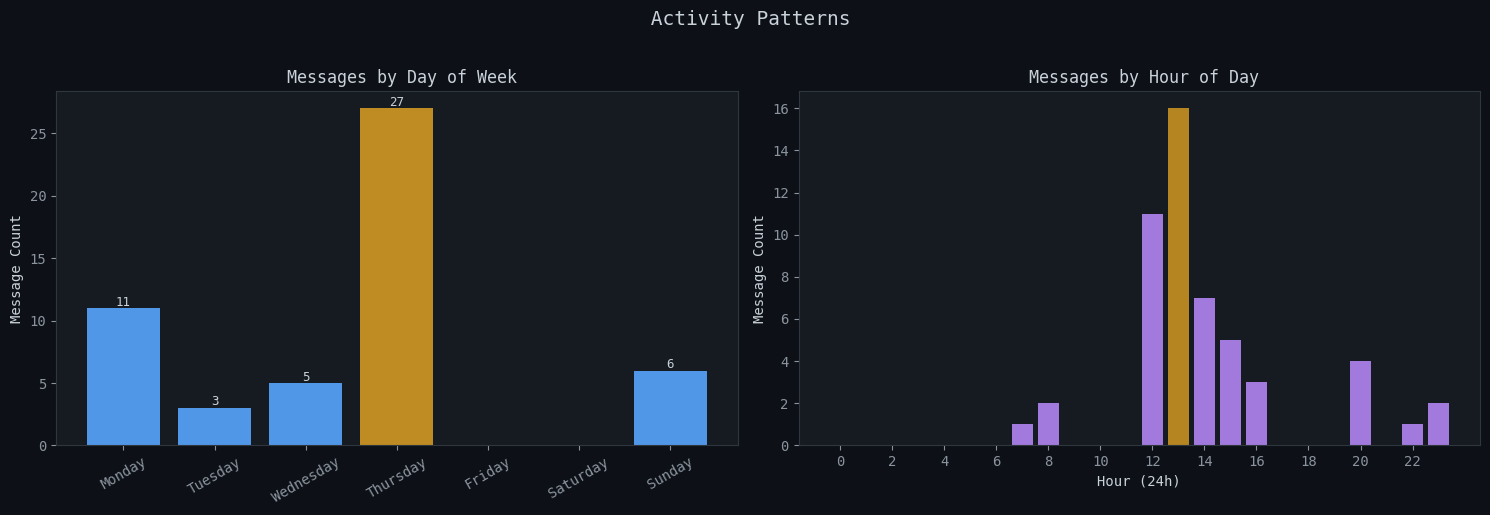

In [23]:
# Day analysis
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = (df['DayOfWeek']
              .value_counts()
              .reindex(day_order)
              .fillna(0)
              .astype(int))

most_active_day = day_counts.idxmax()
print(f' Most Active Day  : {most_active_day}  ({day_counts.max()} messages)')

# Hour analysis
hour_counts = df['Hour'].value_counts().sort_index()
if not hour_counts.empty:
    most_active_hour = hour_counts.idxmax()
    ampm = 'AM' if most_active_hour < 12 else 'PM'
    h12  = most_active_hour % 12 or 12
    print(f' Most Active Time : {h12}:00 {ampm}  ({hour_counts.max()} messages)')
else:
    print('  Hour data not available (datetime parsing issue - check Time format in file)')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Day bar
bar_colors = [PALETTE[3] if d == most_active_day else PALETTE[0] for d in day_counts.index]
axes[0].bar(day_counts.index, day_counts.values, color=bar_colors, alpha=0.9)
axes[0].set_title(' Messages by Day of Week')
axes[0].set_ylabel('Message Count')
axes[0].tick_params(axis='x', rotation=30)
for i, (d, v) in enumerate(day_counts.items()):
    if v > 0:
        axes[0].text(i, v + 0.2, str(v), ha='center', fontsize=9, color='#c9d1d9')

# Hour heatmap-style bar
if not hour_counts.empty:
    full_hours = pd.Series(0, index=range(24))
    full_hours.update(hour_counts)
    h_colors = [PALETTE[3] if h == most_active_hour else PALETTE[4] for h in full_hours.index]
    axes[1].bar(full_hours.index, full_hours.values, color=h_colors, alpha=0.85, width=0.8)
    axes[1].set_title(' Messages by Hour of Day')
    axes[1].set_ylabel('Message Count')
    axes[1].set_xlabel('Hour (24h)')
    axes[1].set_xticks(range(0, 24, 2))
else:
    axes[1].text(0.5, 0.5, 'Hour data unavailable\n(check datetime parsing)',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=11)

plt.suptitle(' Activity Patterns', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

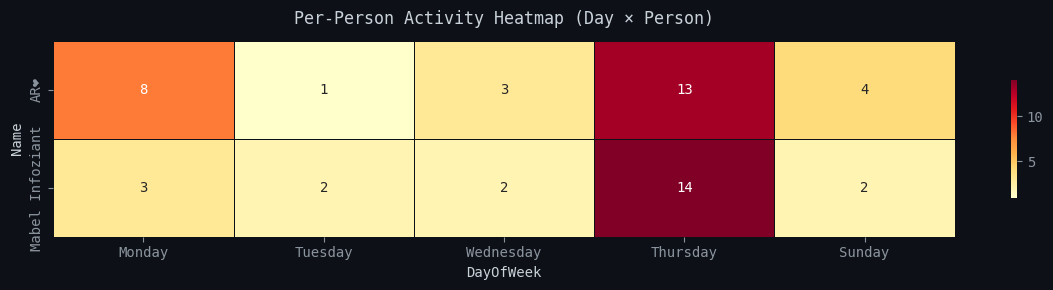

In [24]:
# Per-person active day
person_day = df.groupby(['Name', 'DayOfWeek']).size().reset_index(name='Count')
pivot_day  = person_day.pivot(index='Name', columns='DayOfWeek', values='Count').fillna(0)
pivot_day  = pivot_day.reindex(columns=[d for d in day_order if d in pivot_day.columns])

if not pivot_day.empty:
    fig, ax = plt.subplots(figsize=(12, max(3, len(pivot_day))))
    sns.heatmap(pivot_day.astype(int), annot=True, fmt='d',
                cmap='YlOrRd', ax=ax, linewidths=0.5,
                linecolor='#0d1117', cbar_kws={'shrink': 0.6})
    ax.set_title('Per-Person Activity Heatmap (Day × Person)', pad=12)
    plt.tight_layout()
    plt.show()

---
## 7. Media Count Sent by Each Person

══════════════════════════════════════
   MEDIA COUNT BY PERSON
══════════════════════════════════════
  Mabel Infoziant           █  (1)

  Total Media Messages : 1


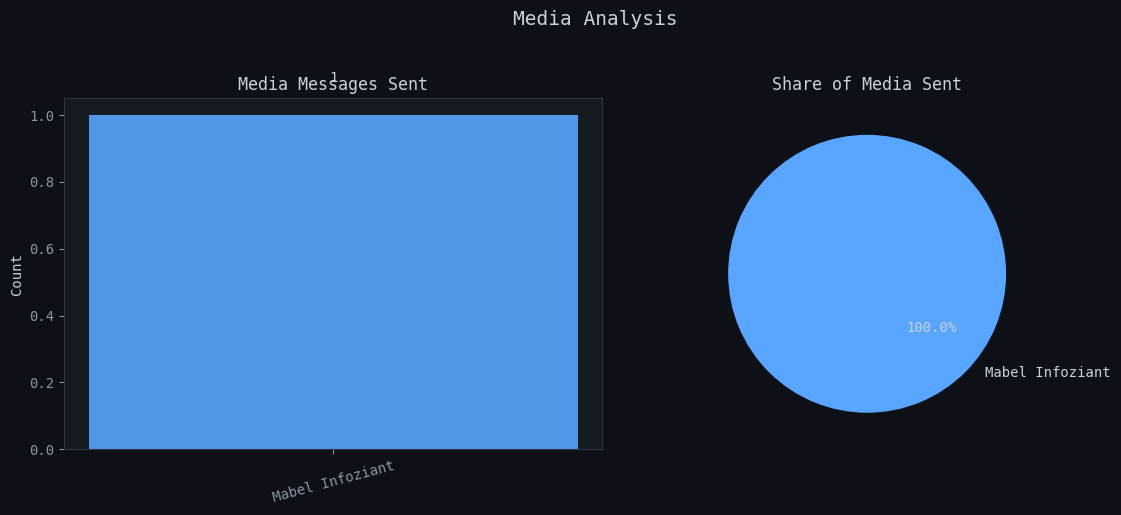

In [25]:
media_df = df[df['Is_Media']].groupby('Name').size().sort_values(ascending=False)

if media_df.empty:
    print('No <Media omitted> tags found — the export may not include them.')
    print('   Searching for any attachment-like messages...')
    # Broaden search
    df['Is_Media_Broad'] = df['Chat'].str.contains(
        r'omitted|attached|image|video|audio|document|sticker|gif', case=False)
    media_df = df[df['Is_Media_Broad']].groupby('Name').size().sort_values(ascending=False)

print('══════════════════════════════════════')
print('   MEDIA COUNT BY PERSON')
print('══════════════════════════════════════')
if not media_df.empty:
    for name, count in media_df.items():
        bar = '█' * count
        print(f'  {name:25s} {bar}  ({count})')
    print(f'\n  Total Media Messages : {media_df.sum()}')

    # Visualise
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].bar(media_df.index, media_df.values,
                color=PALETTE[:len(media_df)], alpha=0.9)
    for i, v in enumerate(media_df.values):
        axes[0].text(i, v + 0.1, str(v), ha='center', fontsize=10, color='#c9d1d9')
    axes[0].set_title('Media Messages Sent')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=15)

    axes[1].pie(media_df.values,
                labels=media_df.index,
                autopct='%1.1f%%',
                colors=PALETTE[:len(media_df)],
                startangle=140,
                wedgeprops={'edgecolor':'#0d1117','linewidth':2})
    axes[1].set_title('Share of Media Sent')
    plt.suptitle('Media Analysis', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('  No media messages found in this chat export.')

---
## 8. Missed Call Analysis

In [32]:
# WhatsApp exports missed calls as system messages; they appear without a sender name
# We also check for explicit patterns in the Chat column

missed_call_patterns = r'missed (voice|video)? ?call|Missed call'

mc_df = df[df['Chat'].str.contains(missed_call_patterns, case=False, na=False)].copy()

print('══════════════════════════════════════════')
print('         MISSED CALL DETAILS')
print('══════════════════════════════════════════')

if mc_df.empty:
    print('  No missed calls found in this chat.')
else:
    print(f'  Total Missed Calls : {len(mc_df)}\n')
    print(mc_df[['Date', 'Time', 'Name', 'Chat']].to_string(index=False))

══════════════════════════════════════════
         MISSED CALL DETAILS
══════════════════════════════════════════
  No missed calls found in this chat.


---
## 9. Full Chat Dashboard - Summary

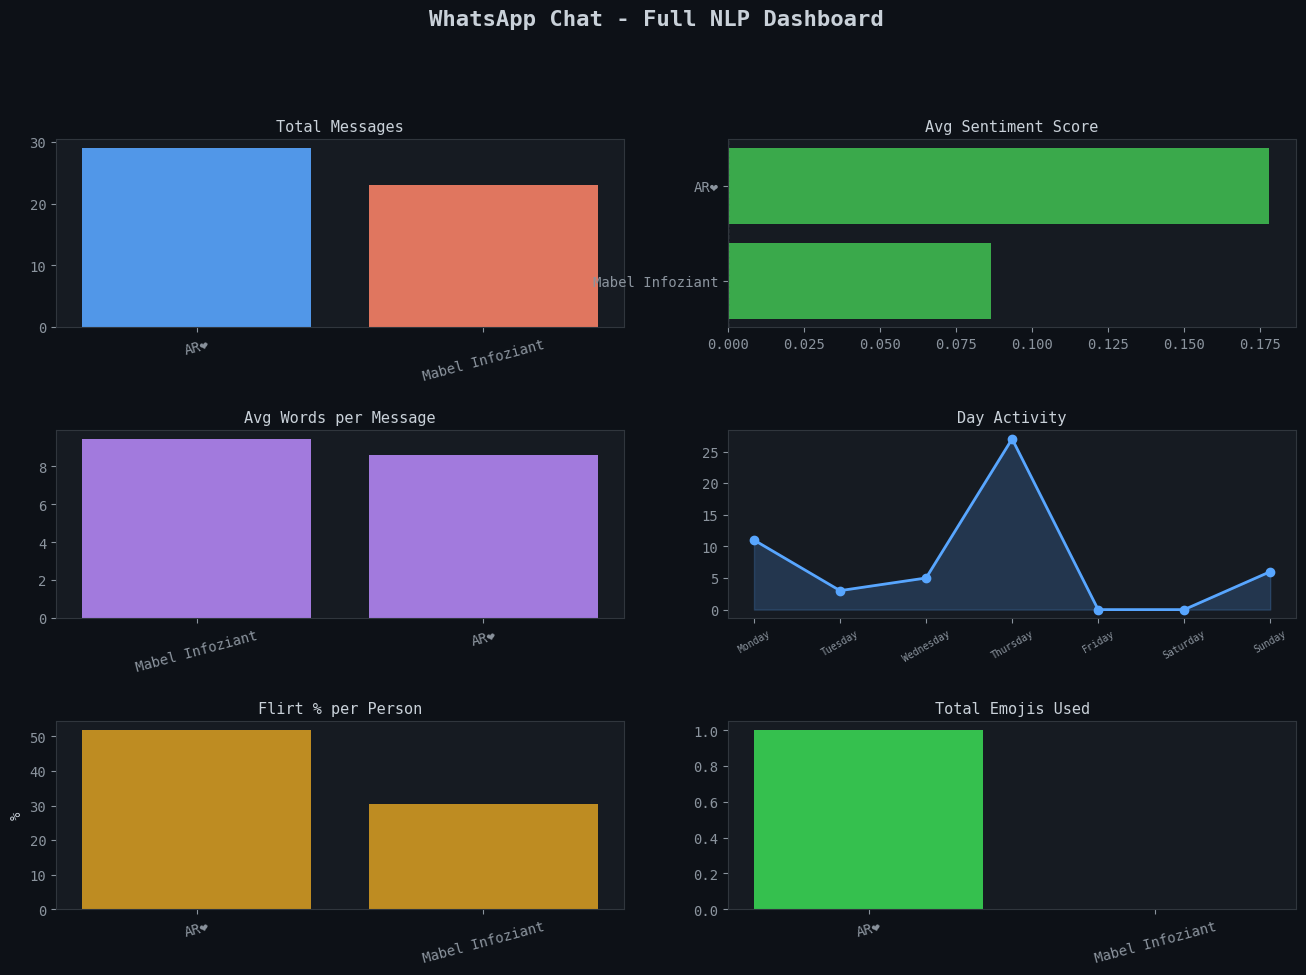

Dashboard saved as whatsapp_dashboard.png


In [29]:
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
gs  = GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.45)

ax1 = fig.add_subplot(gs[0, :2])   # message count
ax2 = fig.add_subplot(gs[0, 2:])   # sentiment
ax3 = fig.add_subplot(gs[1, :2])   # words per msg
ax4 = fig.add_subplot(gs[1, 2:])   # day activity
ax5 = fig.add_subplot(gs[2, :2])   # flirt %
ax6 = fig.add_subplot(gs[2, 2:])   # emoji count

# Message count per person
mc = df['Name'].value_counts()
ax1.bar(mc.index, mc.values, color=PALETTE[:len(mc)], alpha=0.9)
ax1.set_title('Total Messages', fontsize=11)
ax1.tick_params(axis='x', rotation=15)

# Avg sentiment
sent = df.groupby('Name')['Sentiment_Score'].mean().sort_values()
colors_s = [PALETTE[2] if v > 0 else PALETTE[1] for v in sent.values]
ax2.barh(sent.index, sent.values, color=colors_s, alpha=0.9)
ax2.axvline(0, color='white', lw=0.8, ls='--')
ax2.set_title('Avg Sentiment Score', fontsize=11)

# Avg words/msg
wpm = df.groupby('Name')['WordCount'].mean().sort_values(ascending=False)
ax3.bar(wpm.index, wpm.values, color=PALETTE[4], alpha=0.85)
ax3.set_title('Avg Words per Message', fontsize=11)
ax3.tick_params(axis='x', rotation=15)

# Day activity
d = df['DayOfWeek'].value_counts().reindex(day_order).fillna(0)
ax4.plot(d.index, d.values, marker='o', color=PALETTE[0], lw=2)
ax4.fill_between(range(len(d)), d.values, alpha=0.2, color=PALETTE[0])
ax4.set_xticks(range(len(d)))
ax4.set_xticklabels(d.index, rotation=30, fontsize=7)
ax4.set_title('Day Activity', fontsize=11)

# Flirt %
fp = df.groupby('Name')['Flirt_Label'].mean() * 100
ax5.bar(fp.index, fp.values, color=PALETTE[3], alpha=0.9)
ax5.set_title('Flirt % per Person', fontsize=11)
ax5.set_ylabel('%')
ax5.tick_params(axis='x', rotation=15)

# Emoji count
em = df.groupby('Name')['EmojiCount'].sum().sort_values(ascending=False)
ax6.bar(em.index, em.values, color=PALETTE[5], alpha=0.9)
ax6.set_title('Total Emojis Used', fontsize=11)
ax6.tick_params(axis='x', rotation=15)

fig.suptitle('WhatsApp Chat - Full NLP Dashboard', fontsize=16,
             color='#c9d1d9', y=1.01, fontweight='bold')
plt.savefig('whatsapp_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('Dashboard saved as whatsapp_dashboard.png')

---
## 10. Try the Flirt Predictor - Interactive

In [30]:
def predict_flirt(message: str) -> None:
    """
    Given any text message, prints whether it is FLIRTY or NOT.
    """
    label   = final_model.predict([message])[0]
    sid_    = SentimentIntensityAnalyzer()
    senti   = sid_.polarity_scores(message)['compound']
    tag     = 'FLIRTY' if label == 1 else 'NOT FLIRTY'
    senti_t = 'Positive' if senti > 0.05 else ('Negative' if senti < -0.05 else 'Neutral')

    print('═' * 55)
    print(f'  Input      : "{message}"')
    print(f'  Prediction : {tag}')
    print(f'  Sentiment  : {senti_t}  (score={senti:.3f})')
    print('═' * 55)


# Run some examples
test_messages = [
    "Hey beautiful, thinking about you all day!",
    "Please send the updated project report by EOD.",
    "Can't wait to see you again, miss you so much",
    "The meeting is scheduled for tomorrow at 10 AM.",
    "You are so cute and adorable!",
    "Kindly revert on the issue raised in the last sprint.",
]

for msg in test_messages:
    predict_flirt(msg)

═══════════════════════════════════════════════════════
  Input      : "Hey beautiful, thinking about you all day!"
  Prediction : FLIRTY
  Sentiment  : Positive  (score=0.636)
═══════════════════════════════════════════════════════
═══════════════════════════════════════════════════════
  Input      : "Please send the updated project report by EOD."
  Prediction : NOT FLIRTY
  Sentiment  : Positive  (score=0.318)
═══════════════════════════════════════════════════════
═══════════════════════════════════════════════════════
  Input      : "Can't wait to see you again, miss you so much"
  Prediction : FLIRTY
  Sentiment  : Negative  (score=-0.153)
═══════════════════════════════════════════════════════
═══════════════════════════════════════════════════════
  Input      : "The meeting is scheduled for tomorrow at 10 AM."
  Prediction : NOT FLIRTY
  Sentiment  : Neutral  (score=0.000)
═══════════════════════════════════════════════════════
════════════════════════════════════════════════

---
## 11. Final Summary Report

In [34]:
most_talkative  = talk_df.index[0]
least_talkative = talk_df.index[-1]
active_day      = day_counts.idxmax()
top_flirter     = (df.groupby('Name')['Flirt_Label'].mean() * 100).idxmax()

summary = pd.DataFrame({
    'Metric': [
        'Participants', 'Total Messages', 'Date Range',
        'Most Talkative', 'Least Talkative', 'Most Active Day',
        'Top Flirter', 'Best Flirt Model', 'Model CV Accuracy'
    ],
    'Value': [
        df['Name'].nunique(),
        len(df),
        f"{df['Date'].min()} → {df['Date'].max()}",
        most_talkative,
        least_talkative,
        active_day,
        top_flirter,
        best_name,
        f"{results_df.iloc[0]['Mean Accuracy']:.2%}"
    ]
})

summary.set_index('Metric')

,Value
Metric,
Participants,2
Total Messages,52
Date Range,05/12/19 → 18/12/19
Most Talkative,AR❤
Least Talkative,Mabel Infoziant
Most Active Day,Thursday
Top Flirter,AR❤
Best Flirt Model,TFIDF + Naïve Bayes
Model CV Accuracy,89.42%
